# NB01b: Pilot with Refined Continuous Metrics

**Goal**: Re-analyze NB01 pilot data with continuous metrics instead of binary 'any multi-copy in ≥1 genome'. The binary is dominated by rare clusters with a single multi-copy occurrence.

**Revised metrics** (per plan v2):
1. **Cluster-carrier-weighted multi-copy rate**: SUM(multicopy_genomes) / SUM(carrier_genomes) across all clusters in a COG category. This is the probability that a random (cluster, genome) carrier pair is multi-copy — a more informative rate than binary flags.
2. **Mean copies per carrier** across all clusters in a category.
3. **Cluster-level CV of copy count** (STDDEV/AVG), aggregated as mean and quartiles.

**Revised category labels**:
- Housekeeping (strict): F (nucleotide), H (coenzyme).
- Adaptive: L (repair/mobile), V (defense), M (cell wall), K (transcription).
- Mixed (pilot found substantial variance despite housekeeping-like function): C (energy), J (translation).
- Other: all remaining single-letter COGs.

**Revised threshold**: cluster-carrier-weighted adaptive/housekeeping ratio ≥2× (relaxed from 3× on the coarser binary), consistency ≥4/5 pilots.

**Inputs**: `data/pilot_copy_numbers.csv` from NB01
**Outputs**: `data/pilot_refined_metrics.csv`, `figures/pilot_refined_cog_metrics.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')

# Load NB01 output
pilot_df = pd.read_csv(DATA_DIR / 'pilot_copy_numbers.csv')
print(f'Loaded {len(pilot_df):,} cluster-COG rows')
print(f'Species: {pilot_df.phylum.value_counts().to_dict()}')

Loaded 236,326 cluster-COG rows
Species: {'Pseudomonadota': 160533, 'Bacteroidota': 38036, 'Actinomycetota': 20371, 'Bacillota': 11450, 'Spirochaetota': 5936}


## 1. Compute continuous per-cluster metrics

Recall NB01 gave us per-cluster aggregates already. For continuous analysis we need:
- `carrier_multicopy_rate = n_multicopy_genomes / n_genomes_with` — fraction of carriers that carry >1 copy
- `mean_copies_per_carrier` — average copies among genomes that have the cluster
- Cluster CV proxy — STDDEV/mean of copy count (already computed)

In [2]:
pilot_df['carrier_multicopy_rate'] = pilot_df['n_multicopy_genomes'] / pilot_df['n_genomes_with']
pilot_df['cv_copies'] = pilot_df['std_copies'] / pilot_df['mean_copies_per_carrier']
pilot_df['cv_copies'] = pilot_df['cv_copies'].fillna(0)  # single-genome clusters have std=NaN → 0

# Focus on single-letter COG codes (drop composites and unannotated)
single_cog = pilot_df[
    pilot_df['COG_category'].notna() &
    (pilot_df['COG_category'].str.len() == 1) &
    (pilot_df['COG_category'] != '-')
].copy()
print(f'Single-COG clusters: {len(single_cog):,}')

Single-COG clusters: 140,121


## 2. Cluster-carrier-weighted multi-copy rate per COG × phylum

This is the primary revised metric. Aggregates over all clusters weighted by how many carrier-genomes they have. A rare cluster with 1 multi-copy in 1 genome contributes only 1/1 to the numerator and 1 to the denominator, but a common cluster (say core) with 175 carrier-genomes contributes many observations.

In [3]:
def weighted_metrics(group):
    total_multi = group['n_multicopy_genomes'].sum()
    total_carriers = group['n_genomes_with'].sum()
    total_copies = group['total_copies'].sum()
    return pd.Series({
        'n_clusters': group['gene_cluster_id'].nunique(),
        'total_carrier_genomes': int(total_carriers),
        'total_multicopy_genomes': int(total_multi),
        'weighted_multicopy_rate_pct': 100 * total_multi / total_carriers,
        'weighted_mean_copies_per_carrier': total_copies / total_carriers,
        'cluster_mean_cv': group['cv_copies'].mean(),
        'cluster_median_cv': group['cv_copies'].median(),
    })

cog_phylum = single_cog.groupby(['phylum', 'COG_category']).apply(weighted_metrics).reset_index()
print('Per phylum × COG weighted metrics (top 10 by weighted multi-copy rate, pooled):')
print(cog_phylum.sort_values('weighted_multicopy_rate_pct', ascending=False).head(15).to_string())

Per phylum × COG weighted metrics (top 10 by weighted multi-copy rate, pooled):
            phylum COG_category  n_clusters  total_carrier_genomes  total_multicopy_genomes  weighted_multicopy_rate_pct  weighted_mean_copies_per_carrier  cluster_mean_cv  cluster_median_cv
60    Bacteroidota            U       665.0                 9568.0                    356.0                     3.720736                          1.040552         0.038262                0.0
52    Bacteroidota            L      2750.0                33975.0                    775.0                     2.281089                          1.037910         0.027136                0.0
93   Spirochaetota            L       155.0                 8098.0                    156.0                     1.926402                          1.022228         0.029973                0.0
73  Pseudomonadota            L      7935.0                37497.0                    600.0                     1.600128                          1.032056  

## 3. Pooled COG ranking with the new metrics

In [4]:
cog_pooled = single_cog.groupby('COG_category').apply(weighted_metrics).reset_index()
cog_pooled = cog_pooled.sort_values('weighted_multicopy_rate_pct', ascending=False)
print('COG categories ranked by cluster-carrier-weighted multi-copy rate:')
print(cog_pooled.to_string())
cog_pooled.to_csv(DATA_DIR / 'pilot_refined_metrics.csv', index=False)

COG categories ranked by cluster-carrier-weighted multi-copy rate:
   COG_category  n_clusters  total_carrier_genomes  total_multicopy_genomes  weighted_multicopy_rate_pct  weighted_mean_copies_per_carrier  cluster_mean_cv  cluster_median_cv
11            L     12623.0               120628.0                   1761.0                     1.459860                          1.025235         0.017674                0.0
19            U      3641.0                42300.0                    408.0                     0.964539                          1.010496         0.010454                0.0
17            S     34952.0               484682.0                   1771.0                     0.365394                          1.004716         0.005338                0.0
2             C      8435.0               110571.0                    402.0                     0.363567                          1.003735         0.005189                0.0
14            O      3958.0                54915.0        

## 4. Revised class comparison

Revised categories per plan v2:
- **housekeeping** = {F, H}
- **adaptive** = {L, V, M, K}
- **mixed** = {C, J} (excluded from primary test but tracked)

In [5]:
HOUSEKEEPING = {'F', 'H'}
ADAPTIVE = {'L', 'V', 'M', 'K'}
MIXED = {'C', 'J'}

def classify(c):
    if c in HOUSEKEEPING: return 'housekeeping'
    if c in ADAPTIVE: return 'adaptive'
    if c in MIXED: return 'mixed'
    return 'other'

single_cog['class'] = single_cog['COG_category'].apply(classify)

# Per phylum × class
class_phylum = single_cog[single_cog['class'].isin(['adaptive', 'housekeeping'])].groupby(['phylum', 'class']).apply(weighted_metrics).reset_index()
print('Weighted multi-copy rate (%) by class × phylum:')
pivot = class_phylum.pivot(index='phylum', columns='class', values='weighted_multicopy_rate_pct').round(3)
pivot['ratio_adaptive_over_hk'] = (pivot['adaptive'] / pivot['housekeeping']).round(2)
pivot['direction_ok'] = pivot['adaptive'] > pivot['housekeeping']
print(pivot.to_string())

# Pooled
pooled = single_cog[single_cog['class'].isin(['adaptive', 'housekeeping'])].groupby('class').apply(weighted_metrics)
print(f'\nPooled housekeeping weighted multi-copy: {pooled.loc["housekeeping", "weighted_multicopy_rate_pct"]:.3f}%')
print(f'Pooled adaptive weighted multi-copy:     {pooled.loc["adaptive", "weighted_multicopy_rate_pct"]:.3f}%')
print(f'Pooled ratio adaptive/housekeeping:      {pooled.loc["adaptive", "weighted_multicopy_rate_pct"] / pooled.loc["housekeeping", "weighted_multicopy_rate_pct"]:.2f}x')

Weighted multi-copy rate (%) by class × phylum:
class           adaptive  housekeeping  ratio_adaptive_over_hk  direction_ok
phylum                                                                      
Actinomycetota     0.326         0.050                    6.52          True
Bacillota          0.100         0.002                   50.00          True
Bacteroidota       1.008         0.348                    2.90          True
Pseudomonadota     0.516         0.112                    4.61          True
Spirochaetota      0.815         0.905                    0.90         False

Pooled housekeeping weighted multi-copy: 0.169%
Pooled adaptive weighted multi-copy:     0.551%
Pooled ratio adaptive/housekeeping:      3.26x


## 5. Excluding the Spirochaetota outlier

Borreliella's multi-partite genome inflates its multi-copy rate. Re-run the comparison excluding it to check whether the signal is robust.

In [6]:
no_spiro = single_cog[single_cog['phylum'] != 'Spirochaetota']
pooled_nospiro = no_spiro[no_spiro['class'].isin(['adaptive', 'housekeeping'])].groupby('class').apply(weighted_metrics)
print(f'Excluding Spirochaetota:')
print(f'  Pooled housekeeping: {pooled_nospiro.loc["housekeeping", "weighted_multicopy_rate_pct"]:.3f}%')
print(f'  Pooled adaptive:     {pooled_nospiro.loc["adaptive", "weighted_multicopy_rate_pct"]:.3f}%')
print(f'  Ratio:               {pooled_nospiro.loc["adaptive", "weighted_multicopy_rate_pct"] / pooled_nospiro.loc["housekeeping", "weighted_multicopy_rate_pct"]:.2f}x')

Excluding Spirochaetota:
  Pooled housekeeping: 0.128%
  Pooled adaptive:     0.538%
  Ratio:               4.22x


## 6. Cluster-level CV analysis (secondary metric)

Per-cluster CV of copy count captures within-cluster variance. Compare distributions between classes.

In [7]:
from scipy import stats

# Filter to clusters with ≥5 carrier-genomes (need enough for CV to be meaningful)
sub = single_cog[single_cog['n_genomes_with'] >= 5].copy()

hk_cv = sub[sub['class'] == 'housekeeping']['cv_copies']
ad_cv = sub[sub['class'] == 'adaptive']['cv_copies']

print(f'Housekeeping clusters (n={len(hk_cv):,}): mean CV = {hk_cv.mean():.4f}, median = {hk_cv.median():.4f}')
print(f'Adaptive clusters (n={len(ad_cv):,}): mean CV = {ad_cv.mean():.4f}, median = {ad_cv.median():.4f}')

# Mann-Whitney U test (nonparametric — CV distributions are heavy-tailed)
u, p = stats.mannwhitneyu(ad_cv, hk_cv, alternative='greater')
print(f'\nMann-Whitney U (adaptive > housekeeping): U={u:.0f}, p={p:.2e}')

Housekeeping clusters (n=2,360): mean CV = 0.0081, median = 0.0000
Adaptive clusters (n=8,323): mean CV = 0.0224, median = 0.0000

Mann-Whitney U (adaptive > housekeeping): U=10100568, p=1.57e-07


## 7. Refined pilot visualization

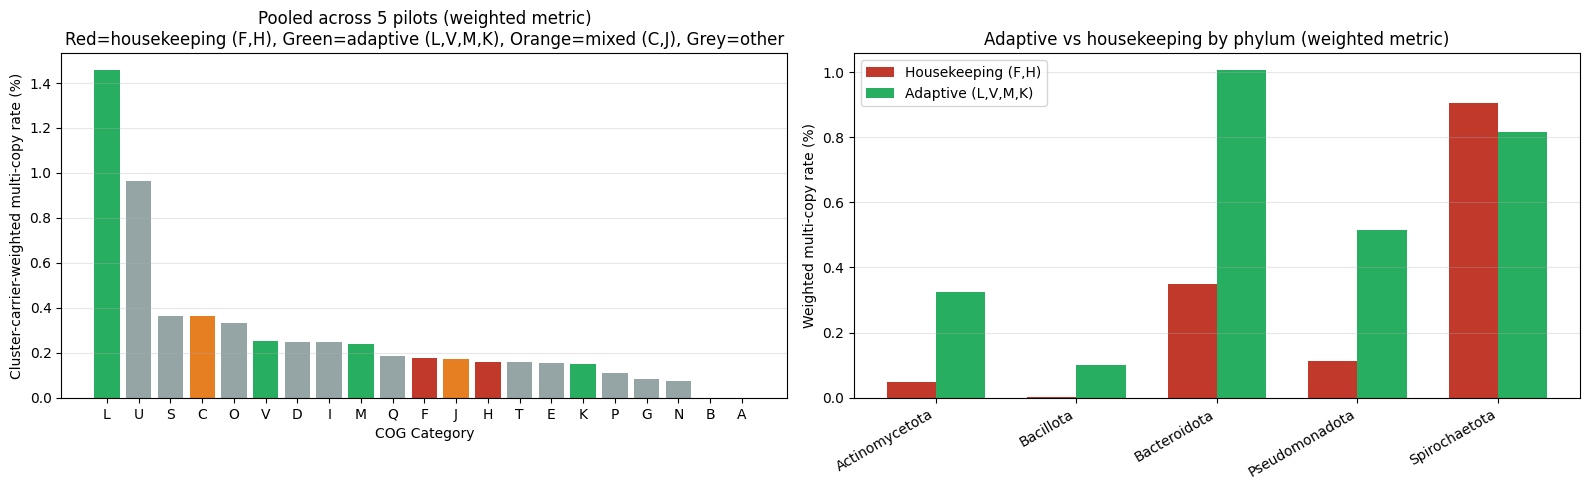

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: pooled COG ranking with weighted metric
def color_class(c):
    if c in HOUSEKEEPING: return '#c0392b'
    if c in ADAPTIVE: return '#27ae60'
    if c in MIXED: return '#e67e22'
    return '#95a5a6'

colors = [color_class(c) for c in cog_pooled['COG_category']]
axes[0].bar(cog_pooled['COG_category'], cog_pooled['weighted_multicopy_rate_pct'], color=colors)
axes[0].set_xlabel('COG Category')
axes[0].set_ylabel('Cluster-carrier-weighted multi-copy rate (%)')
axes[0].set_title('Pooled across 5 pilots (weighted metric)\n'
                  'Red=housekeeping (F,H), Green=adaptive (L,V,M,K), Orange=mixed (C,J), Grey=other')
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: per-phylum ratio
adapt_by_phy = single_cog[single_cog['class'] == 'adaptive'].groupby('phylum').apply(weighted_metrics)['weighted_multicopy_rate_pct']
hk_by_phy = single_cog[single_cog['class'] == 'housekeeping'].groupby('phylum').apply(weighted_metrics)['weighted_multicopy_rate_pct']
phyla = sorted(single_cog['phylum'].unique())
x = np.arange(len(phyla))
width = 0.35
axes[1].bar(x - width/2, [hk_by_phy.get(p, 0) for p in phyla], width, label='Housekeeping (F,H)', color='#c0392b')
axes[1].bar(x + width/2, [adapt_by_phy.get(p, 0) for p in phyla], width, label='Adaptive (L,V,M,K)', color='#27ae60')
axes[1].set_xticks(x)
axes[1].set_xticklabels(phyla, rotation=30, ha='right')
axes[1].set_ylabel('Weighted multi-copy rate (%)')
axes[1].set_title('Adaptive vs housekeeping by phylum (weighted metric)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'pilot_refined_cog_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Pilot verdict with revised thresholds

Criteria (plan v2):
- **Direction**: adaptive > housekeeping in ≥4/5 pilots
- **Magnitude**: cluster-carrier-weighted ratio ≥2× at pooled level, robust to Spirochaetota exclusion
- **Statistical**: Mann-Whitney adaptive > housekeeping on cluster CVs at p<0.05

In [9]:
direction_ok = pivot['direction_ok'].sum()
pooled_ratio = pooled.loc['adaptive', 'weighted_multicopy_rate_pct'] / pooled.loc['housekeeping', 'weighted_multicopy_rate_pct']
nospiro_ratio = pooled_nospiro.loc['adaptive', 'weighted_multicopy_rate_pct'] / pooled_nospiro.loc['housekeeping', 'weighted_multicopy_rate_pct']

print('=' * 60)
print('PILOT VERDICT (plan v2 criteria)')
print('=' * 60)
print(f'1. Direction (adaptive > housekeeping) in ≥4/5 pilots: {direction_ok}/5 — {"✅ PASS" if direction_ok >= 4 else "❌ FAIL"}')
print(f'2. Pooled ratio ≥2×: {pooled_ratio:.2f}× — {"✅ PASS" if pooled_ratio >= 2 else "❌ FAIL"}')
print(f'3. Ratio robust to Spirochaetota exclusion (still ≥2×): {nospiro_ratio:.2f}× — {"✅ PASS" if nospiro_ratio >= 2 else "❌ FAIL"}')
print(f'4. Mann-Whitney CV test p<0.05: p={p:.2e} — {"✅ PASS" if p < 0.05 else "❌ FAIL"}')
print()
n_pass = sum([direction_ok >= 4, pooled_ratio >= 2, nospiro_ratio >= 2, p < 0.05])
print(f'Overall: {n_pass}/4 criteria met → {"PROCEED to NB02 (multi-species scale-up)" if n_pass >= 3 else "HALT and reconsider hypothesis operationalization"}')

PILOT VERDICT (plan v2 criteria)
1. Direction (adaptive > housekeeping) in ≥4/5 pilots: 4/5 — ✅ PASS
2. Pooled ratio ≥2×: 3.26× — ✅ PASS
3. Ratio robust to Spirochaetota exclusion (still ≥2×): 4.22× — ✅ PASS
4. Mann-Whitney CV test p<0.05: p=1.57e-07 — ✅ PASS

Overall: 4/4 criteria met → PROCEED to NB02 (multi-species scale-up)
